In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

# !pip install brokenaxes
import os
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import math
import brokenaxes
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils
from hbn.visualization.stats import perform_flexible_proportion_comparison

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
## PLOTTING FUNCTIONS ##

def get_plot_data(groups, df, col='PreInt_TxHx,psych_meds_cur', col_values=[1], groupby='sex'):
        df_perc_all = pd.DataFrame()
        for dx in groups:
                c_group = dx.copy(); o_group = dx.copy() # initialize two groups
                key = list(dx.keys())[0]
                c_group.update({'age_round': list(np.arange(6,18)),
                                col: col_values})
                new_list = col_values + [0]
                o_group.update({'age_round': list(np.arange(6,18)),
                                col: new_list})
                df_perc = vis.calculate_slopes(df, c_group, o_group, groupby=groupby)
                df_perc['DX'] = dx[key][0]
                df_perc_all = pd.concat([df_perc_all, df_perc])

        return df_perc_all


def _map_med_type():
    # assign medication types to groups
    med_groups = ['ADHD meds.', 'Mood Stabilizers', 'Antipsychotics']
    med_types = [
                ['Concerta', 'Stimulant', 'ADHD-Stimulant', 
                'Adderall', 'stimulant', 'Ritalin', 'Vyvanse - 2 years ago',
                'ADHD-Non Stimulant', 'Intuniv ER'],
                ['Zoloft', 'Lexapro - nothing', 'Antianxiety Drugs', 'Mood Stabilizers',
                'Buspar', 'Other Anti-Depressants', 'Tricyclics', 'SSRI'],
                ['Antipsychotics', 'Latuda - nothing', 'Abiify']
                ]

    df_med_all = pd.DataFrame()
    for med, med_type in zip(med_groups, med_types):
        df_med = pd.DataFrame()
        df_med['med_group'] = np.tile(med, len(med_type))
        df_med['med_type'] = med_type
        df_med_all = pd.concat([df_med_all, df_med], axis=0)

    return df_med_all

def check_med_type(x, med_type='cur'):
    if med_type=='cur':
        cols = range(1,6)
    elif med_type=='past':
        cols = range(6,11)

    # get list of cur med cols
    med_cols = [f'PreInt_TxHx,pmed_{str(i).zfill(2)}_type' for i in cols]

    # get mapping between med types and med groups
    df_med = _map_med_type()

    # check to see if patient is currently taking medication
    medicated = x[f'PreInt_TxHx,psych_meds_{med_type}']==1
    
    # loop over med col
    adhd_meds_count, mood_meds_count, anti_meds_count = 0, 0, 0
    if medicated.values[0]:
        for med_col in med_cols:

            # check if med is in med group
            med = x[med_col].unique()[0]
            if med in df_med['med_type'].tolist():
                med_group = df_med[df_med['med_type']==med]['med_group'].values[0]
                if med_group == 'ADHD meds.':
                    adhd_meds_count += 1
                elif med_group == 'Mood Stabilizers':
                    mood_meds_count += 1
                elif med_group == 'Antipsychotics':
                    anti_meds_count += 1

    df_out = pd.DataFrame.from_dict(
                {f'ADHD meds. ({med_type})': [adhd_meds_count], 
                f'Mood Stabiliziers ({med_type})': [mood_meds_count], 
                f'Antipsychotics ({med_type})': [anti_meds_count]}
                )
    # fill N/A with 0
    df_out = df_out.fillna(0)

    return df_out

# get all dx
def map_parents_dx(x):
      # map dx
      dx_dict = {
            'ADHD': ['ADHD', 'ADHD Inattentive'],
            'No Diagnosis': ['No Diagnosis', 'no diagnosis', 'Other', 'Other Diagnosis', '0No Diagnosis', 'No Response', 'no clinical diagnosis (see below)'],
            'Depressive Disorders': ['Major Depressive Disorder', 'Major Depression', 'depression', 
            'Depression', 'Other Diagnosis: Clinical Depression'],
            'Bipolar Disorder': ['Bipolar II', 'Bipolar (Type Unknown)', 'Bipolar I'],
            'Anxiety Disorders': ['Generalized Anxiety', 'Genarlized Anxiety', 
            'Anxiety', 'Other Anxiety', 'Generalized Anxiety', 'Generalized Anxiety Disorder',
            'Social Phobia', 'Panic Disorder'],
            'OCD': ['OCD'],
            'Schizophrenia': ['Schizophrenia'],
            'Personality Disorder': ['Borderline Personality Disorder', 'Other Personality Disorder'],
            'No Response': ['No Response']
            }
      # loop over dictionary
      out = 'Other'
      for k,v in dx_dict.items():
            if x in v:
                  out = k
      return out


In [4]:
# load data
release = 'Release11_Apr2024'
df = pd.read_csv(os.path.join(Defaults.INTERIM_FEATURES_DIR, release, 'participant_train_test.csv'))

compare_groups = [
                  {'DX_Subtype_Name': ['ADHD-Combined Type']},
                  {'DX_Subtype_Name': ['ADHD-Inattentive Type']},
                  {'DX_Subtype_Name': ['ADHD-Hyperactive/Impulsive Type']},
                  {'DX_Subtype_Name': ['Other Specified Attention-Deficit/Hyperactivity Disorder', 'Unspecified Attention-Deficit/Hyperactivity Disorder']},
                  {'DX_ADHD': ['adhd_all_comorbidities']},
                  {'DX_ADHD': ['adhd_no_comorbidities']},
                  {'DX_Cat_Name_New': ['ADHD']},
                  {'DX_Cat_Name_New': ['Anxiety Disorders']},
                  {'DX_Cat_Name_New': ['Depressive Disorders']},
                  {'DX_Cat_Name_New': ['No Diagnosis Given']},
                  {'DX_Cat_Name_New': ['Autism Spectrum Disorder']},
                  {'DX_Cat_Name_New': ['Neurodevelopmental Disorders']}
                  ] 

### Figure 1
* how do rates of ADHD diagnosis differ across boys and girls? 

<Figure size 900x600 with 0 Axes>

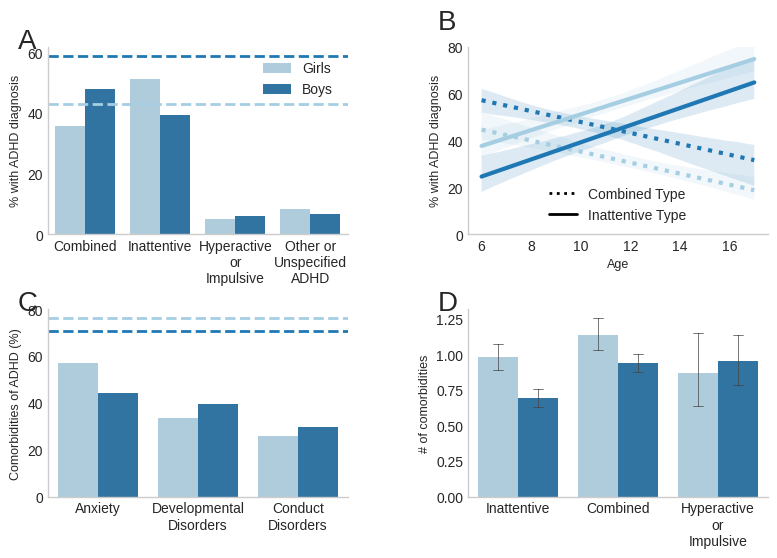

In [5]:
vis.plotting_style()
 

fig = plt.figure(figsize=(9,6))
gs = GridSpec(2, 2, figure=fig)

# prepare data
all_dx = df['DX_Cat_Name_New'].unique().tolist()
overall_group = {'DX_Cat_Name_New': all_dx,
                'age_round': list(np.arange(6,18))}
df_A_overall = pd.DataFrame()
for group in compare_groups:
    key = list(group.keys())[0]
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group, groupby=['sex'])
    df_perc['DX'] = group[key][0]
    df_A_overall = pd.concat([df_A_overall, df_perc])  
df_A_overall['sex'] = df_A_overall['sex'].map({'female': 'Girls', 'male': 'Boys'})

overall_group = {'DX_Cat_Name_New': 'ADHD',
                 'age_round': list(np.arange(6,18))}
df_perc_all = pd.DataFrame()
for group in compare_groups:
    key = list(group.keys())[0]
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group, groupby=['sex'])
    df_perc['DX'] = group[key][0]
    df_perc_all = pd.concat([df_perc_all, df_perc]) 
df_perc_all['sex'] = df_perc_all['sex'].map({'female': 'Girls', 'male': 'Boys'})

fig = plt.figure(figsize=(9,6))
gs = GridSpec(2, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0, 0])

df_A = df_perc_all[df_perc_all['DX'].isin(['ADHD-Combined Type', 'ADHD-Inattentive Type', 'ADHD-Hyperactive/Impulsive Type', 
                                          'Other Specified Attention-Deficit/Hyperactivity Disorder', 'Unspecified Attention-Deficit/Hyperactivity Disorder'])]   
ax = vis.barplot(df_A, ax=ax, y='perc', x='DX', hue='sex', ylabel='% with ADHD diagnosis', 
            ylim=None, bbox_to_anchor=(.7, .95), subplot='A',
            xticklabels=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD'])

# add lineplot for overall ADHD (boys and girls)
f_overall = df_A_overall[(df_A_overall['DX']=='ADHD') & (df_A_overall['sex']=='Girls')]['perc']
m_overall = df_A_overall[(df_A_overall['DX']=='ADHD') & (df_A_overall['sex']=='Boys')]['perc']

palette = sns.color_palette('Paired')
ax.axhline(y=int(f_overall), color=palette[0], linestyle='dashed')
ax.axhline(y=int(m_overall), color=palette[1], linestyle='dashed')

# B
df_perc_all = pd.DataFrame()
for group in compare_groups:
    key = list(group.keys())[0]
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group, groupby=['sex', 'age_round'])
    df_perc['DX'] = group[key][0]
    df_perc_all = pd.concat([df_perc_all, df_perc]) 

ax = fig.add_subplot(gs[0, 1])
df_B = df_perc_all[df_perc_all['DX'].isin(['ADHD-Combined Type'])]
vis.plot_slopes(df=df_B, ax=ax, hue='sex', fit_reg=False, ylabel='% with ADHD diagnosis', marker=None, 
                linestyle='dotted', ylim=[0,80])
df_B = df_perc_all[df_perc_all['DX'].isin(['ADHD-Inattentive Type'])]
ax = vis.plot_slopes(df=df_B, ax=ax, hue='sex', ylabel='% with ADHD diagnosis', marker=None, 
                linestyle='solid', ylim=[0,80], fit_reg=False, legend=False, subplot='B')

# add legend to B
from matplotlib.lines import Line2D
line1 = Line2D([0], [0], color='black', linestyle='dotted', label='Combined Type')
line2 = Line2D([0], [0], color='black', linestyle='solid', label='Inattentive Type')
# Add the custom legend to the axes
ax.legend(handles=[line1, line2])

# C
df_C = pd.DataFrame()
for dx in all_dx:
    df_adhd = df[df['DX_ADHD']=='adhd_all_comorbidities']
    df_dx = df_adhd[df_adhd['DX_Cat_Name_New']==dx]
    try:
        df_count = df_dx.groupby('sex').apply(lambda x: len(x['Identifiers'].unique())).reset_index(name='count')
        df_overall = df_adhd.groupby('sex').apply(lambda x: len(x['Identifiers'].unique())).reset_index(name='overall_count')
        df_count = df_count.merge(df_overall, on='sex')
        df_count['DX'] = dx
        df_count['perc'] = (df_count['count'] / df_count['overall_count']) *100
        df_C = pd.concat([df_C, df_count])
    except:
        pass

ax = fig.add_subplot(gs[1, 0])
data = df_C.sort_values(by='perc', ascending=False).groupby('sex').head(4)
ax = vis.barplot(data.iloc[2:], ax=ax, x='DX', hue='sex', y="perc", ylabel='Comorbidities of ADHD (%)', 
            ylim=None, bbox_to_anchor=(.7, 1.1), subplot='C', legend=False, 
            xticklabels=['Anxiety', 'Developmental Disorders', 'Conduct Disorders']
            )

# get overall comorbiditiy burden
# of all girls with ADHD, what % of them have a comorbiditiy? (same for boys)
df_count = df[df['DX_ADHD']=='adhd_all_comorbidities'].groupby('sex').apply(lambda x: len(x['Identifiers'].unique())).reset_index(name='count')
df_overall = df[df['DX_Cat_Name_New']=='ADHD'] .groupby('sex').apply(lambda x: len(x['Identifiers'].unique())).reset_index(name='overall_count')
df_count = df_count.merge(df_overall, on='sex')
df_count['perc'] = (df_count['count'] / df_count['overall_count']) *100

# add legend to C
palette = sns.color_palette('Paired')
f_overall = df_count[df_count['sex']=='female']['perc'].iloc[0]
m_overall = df_count[df_count['sex']=='male']['perc'].iloc[0]
ax.axhline(y=f_overall, color=palette[0], linestyle='dashed')
ax.axhline(y=m_overall, color=palette[1], linestyle='dashed')

# D
ax = fig.add_subplot(gs[1, 1])
df_D = df[df['DX_Subtype_Name'].isin(['ADHD-Inattentive Type', 'ADHD-Combined Type', 'ADHD-Hyperactive/Impulsive Type'])]
vis.barplot(df_D.sort_values(by='sex'), ax=ax, x='DX_Subtype_Name', hue='sex', y="comorbidities_DX_Cat", ylabel='# of comorbidities', 
            ylim=None, bbox_to_anchor=(.7, 1.1), subplot='D', legend=False,
            xticklabels=['Inattentive','Combined', 'Hyperactive or Impulsive'])

plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.90, wspace=0.4, hspace=0.4)

In [31]:
# STATS FOR FIGURE 1

# STATS SUMMARY - A
print('SUMMARY STATS FOR (A) \n')
print(df_A)

results_dx_overall = perform_flexible_proportion_comparison(
    df=df_A,
    compare_col='sex',
    count_col='count',
    overall_count_col='overall_count',
    group_col='DX'
)
print("\nResults comparing SIG. FOR A:")
print(results_dx_overall)

print('SUMMARY STATS FOR (A) -- overall \n')
for sex in ['Girls', 'Boys']:
    print(df_A_overall[(df_A_overall['DX']=='ADHD') & (df_A_overall['sex']==sex)])

# STATS SUMMARY - B
print('SUMMARY STATS FOR (B) \n')
print(df_B)

# STATS SUMMARY - C
print('SUMMARY STATS FOR (C) \n')
print(df_C)

# results_dx_overall = perform_flexible_proportion_comparison(
#     df=df_C,
#     compare_col='sex',
#     count_col='count',
#     overall_count_col='overall_count',
#     group_col='DX'
# )
# print("\nResults comparing DX overall:")
# print(results_dx_overall)

# # STATS SUMMARY - D
# print('SUMMARY STATS FOR (D) \n')
# print(df_D)


SUMMARY STATS FOR (A) 

     sex       perc count  overall_count        sex_plot  \
0  Girls  35.624123   254            713  female (n=254)   
3   Boys  48.111563   828           1721    male (n=828)   
0  Girls  51.332398   366            713  female (n=366)   
3   Boys  39.511912   680           1721    male (n=680)   
0  Girls   4.908836    35            713   female (n=35)   
3   Boys   5.868681   101           1721    male (n=101)   
0  Girls   8.415147    60            713   female (n=60)   
3   Boys   6.624056   114           1721    male (n=114)   

                                                  DX  index  
0                                 ADHD-Combined Type    NaN  
3                                 ADHD-Combined Type    NaN  
0                              ADHD-Inattentive Type    NaN  
3                              ADHD-Inattentive Type    NaN  
0                    ADHD-Hyperactive/Impulsive Type    NaN  
3                    ADHD-Hyperactive/Impulsive Type    NaN  
0


--- Results with Holm-Bonferroni Correction (Grouped by 'DX') ---

--- Comparison: Girls vs. Boys (within DX = 'ADHD-Combined Type') ---
Z-statistic: -10.046
Uncorrected P-value: 0.000
Holm-Bonferroni Corrected P-value: 0.000
Reject null hypothesis at alpha=0.05.
There is a significant difference in rates between Girls and Boys.

--- Comparison: Girls vs. Boys (within DX = 'ADHD-Inattentive Type') ---
Z-statistic: -1.002
Uncorrected P-value: 0.316
Holm-Bonferroni Corrected P-value: 0.633
Fail to reject null hypothesis at alpha=0.05.
There is no significant difference in rates between Girls and Boys.

--- Comparison: Girls vs. Boys (within DX = 'Generalized Anxiety Disorder') ---
Z-statistic: 7.999
Uncorrected P-value: 0.000
Holm-Bonferroni Corrected P-value: 0.000
Reject null hypothesis at alpha=0.05.
There is a significant difference in rates between Girls and Boys.

--- Comparison: Girls vs. Boys (within DX = 'Oppositional Defiant Disorder') ---
Z-statistic: -2.666
Uncorrected P-val

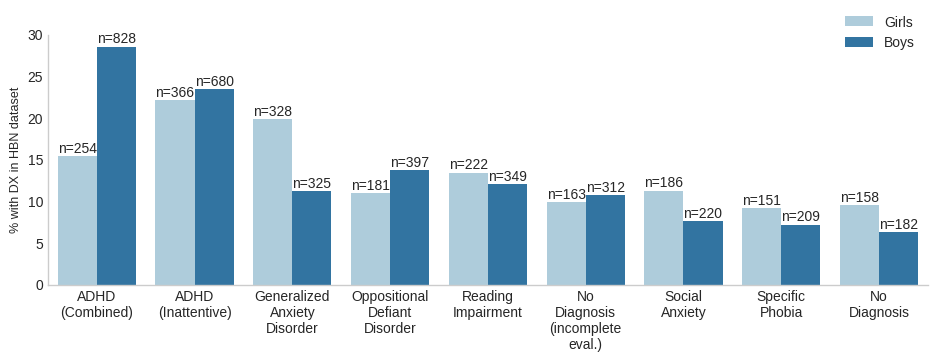

In [35]:
vis.plotting_style()
 
all_dx = df['DX_Subtype_Name'].unique().tolist()
overall_group = {'DX_Subtype_Name': all_dx,
                 'age_round': list(np.arange(6,18))}

top_dx = df['DX_Subtype_Name'].value_counts().reset_index()['DX_Subtype_Name'].head(9).tolist()
groups_to_compare = []
for dx in top_dx:
    groups_to_compare.append({'DX_Subtype_Name': [dx]})

df_perc_all = pd.DataFrame()
for group in groups_to_compare:
    key = list(group.keys())[0]
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group, groupby=['sex'])
    df_perc['DX'] = group[key][0]
    df_perc_all = pd.concat([df_perc_all, df_perc])  

fig = plt.figure(figsize=(11,8))
gs = GridSpec(2, 2, figure=fig)

# # A
ax = fig.add_subplot(gs[0, :])
data_to_plot = df_perc_all[df_perc_all['DX'].isin(all_dx)]   
data_to_plot['sex'] = data_to_plot['sex'].map({'female': 'Girls', 'male': 'Boys'})
vis.barplot(data_to_plot, ax=ax, y='perc', x='DX', hue='sex', ylabel='% with DX in HBN dataset', 
            ylim=[0,30], bbox_to_anchor=(.9, 1.1), 
            xticklabels=['ADHD (Combined)', 'ADHD (Inattentive)', 'Generalized Anxiety Disorder', 'Oppositional Defiant Disorder', 'Reading Impairment',
                         'No Diagnosis (incomplete eval.)', 'Social Anxiety', 'Specific Phobia', 'No Diagnosis']
            )

# Iterate through the bars and add text labels
text_vals = []
for sex in ['Girls', 'Boys']:
    text_vals.extend(data_to_plot[data_to_plot['sex']==sex]['count'].tolist())
for (p, text) in zip(ax.patches, text_vals):
    # Adjust the text position and format as needed
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.1, f'n={text}', ha='center', va='bottom')                

results_dx_overall = perform_flexible_proportion_comparison(
    df=data_to_plot,
    compare_col='sex',
    count_col='count',
    overall_count_col='overall_count',
    group_col='DX'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.90, wspace=0.4, hspace=0.4)

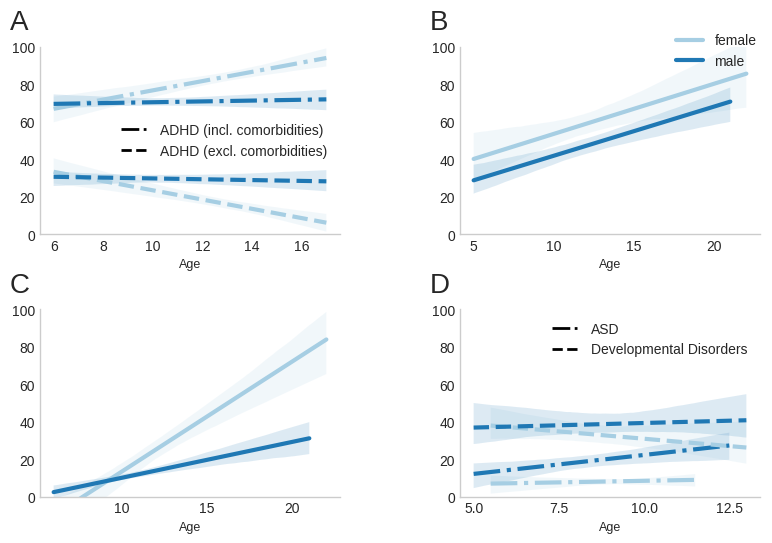

In [ ]:

fig = plt.figure(figsize=(9,6))
gs = GridSpec(2, 2, figure=fig)

# A
overall_group = {'DX_Cat_Name_New': 'ADHD',
                 'age_round': list(np.arange(6,18))}

df_perc_all = pd.DataFrame()
for group in compare_groups:
    key = list(group.keys())[0]
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group, groupby=['sex', 'age_round'])
    df_perc['DX'] = group[key][0]
    df_perc_all = pd.concat([df_perc_all, df_perc]) 

ax = fig.add_subplot(gs[0, 0])
data_to_plot = df_perc_all[df_perc_all['DX']=='adhd_all_comorbidities']
vis.plot_slopes(data_to_plot, ax=ax, hue='sex', ylabel='', marker=None, 
                linestyle='dashdot')
data_to_plot = df_perc_all[df_perc_all['DX']=='adhd_no_comorbidities']
vis.plot_slopes(data_to_plot, ax=ax, hue='sex', ylabel='', marker=None, 
                linestyle='dashed', legend=False, subplot='A')
# add legend to B
from matplotlib.lines import Line2D
line1 = Line2D([0], [0], color='black', linestyle='dashdot', label='ADHD (incl. comorbidities)')
line2 = Line2D([0], [0], color='black', linestyle='dashed', label='ADHD (excl. comorbidities)')
# Add the custom legend to the axes
ax.legend(handles=[line1, line2])


# B
df_count_all = pd.DataFrame()
for dx in ['Anxiety Disorders', 'Depressive Disorders', 'Autism Spectrum Disorder', 'Neurodevelopmental Disorders']:
    df_adhd = df[df['DX_ADHD']=='adhd_all_comorbidities']
    df_dx = df_adhd[df_adhd['DX_Cat_Name_New']==dx]
    df_count = df_dx.groupby(['sex', 'age_round']).apply(lambda x: len(x['Identifiers'].unique())).reset_index(name='count')
    df_overall = df_adhd.groupby(['sex', 'age_round']).apply(lambda x: len(x['Identifiers'].unique())).reset_index(name='overall')
    df_count = df_count.merge(df_overall, on=['sex', 'age_round'])
    df_count['DX'] = dx
    df_count['perc'] = (df_count['count'] / df_count['overall']) *100
    df_count_all = pd.concat([df_count_all, df_count])

ax = fig.add_subplot(gs[0, 1])
data_to_plot = df_count_all[df_count_all['DX']=='Anxiety Disorders']
vis.plot_slopes(data_to_plot, ax=ax, hue='sex', ylabel='', marker=None, 
                subplot='B', bbox_to_anchor=(.7, 1.1), linestyle='solid')

# C
ax = fig.add_subplot(gs[1, 0])
data_to_plot = df_count_all[df_count_all['DX']=='Depressive Disorders']
vis.plot_slopes(data_to_plot, ax=ax, hue='sex', legend=False, ylabel='', marker=None, 
                linestyle='solid',subplot='C')

# D
ax = fig.add_subplot(gs[1, 1])
data_to_plot = df_count_all[df_count_all['DX']=='Autism Spectrum Disorder']
vis.plot_slopes(data_to_plot, ax=ax, hue='sex', legend=False, ylabel='', marker=None, 
                linestyle='dashdot')
data_to_plot = df_count_all[df_count_all['DX']=='Neurodevelopmental Disorders']
vis.plot_slopes(data_to_plot, ax=ax, hue='sex', legend=False, ylabel='', marker=None, 
                linestyle='dashed', subplot='D')
from matplotlib.lines import Line2D
line1 = Line2D([0], [0], color='black', linestyle='dashdot', label='ASD')
line2 = Line2D([0], [0], color='black', linestyle='dashed', label='Developmental Disorders')
# Add the custom legend to the axes
ax.legend(handles=[line1, line2])

plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.90, wspace=0.4, hspace=0.4)

### Supp Figure 2

Rates of diagnosis for all disorders across age

### Figure 2
* What about rate of medication across boys and girls? 


--- Results with Holm-Bonferroni Correction (Grouped by 'DX') ---

--- Comparison: Girls vs. Boys (within DX = 'ADHD-Combined Type') ---
Z-statistic: -1.898
Uncorrected P-value: 0.058
Holm-Bonferroni Corrected P-value: 0.231
Fail to reject null hypothesis at alpha=0.05.
There is no significant difference in rates between Girls and Boys.

--- Comparison: Girls vs. Boys (within DX = 'ADHD-Inattentive Type') ---
Z-statistic: -0.992
Uncorrected P-value: 0.321
Holm-Bonferroni Corrected P-value: 0.964
Fail to reject null hypothesis at alpha=0.05.
There is no significant difference in rates between Girls and Boys.

--- Comparison: Girls vs. Boys (within DX = 'ADHD-Hyperactive/Impulsive Type') ---
Z-statistic: -0.617
Uncorrected P-value: 0.537
Holm-Bonferroni Corrected P-value: 1.000
Fail to reject null hypothesis at alpha=0.05.
There is no significant difference in rates between Girls and Boys.

--- Comparison: Girls vs. Boys (within DX = 'Other Specified Attention-Deficit/Hyperactivity Diso

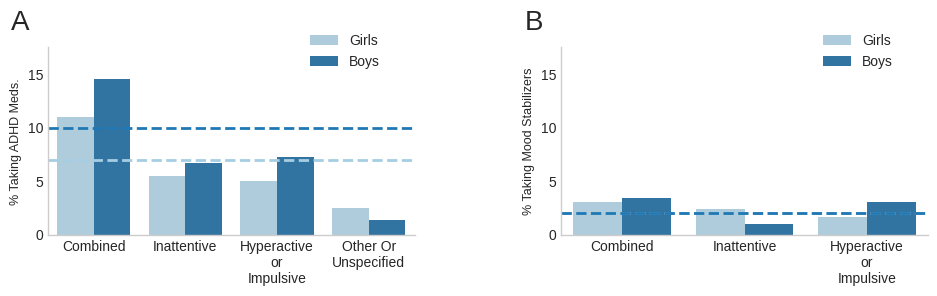

In [70]:
vis.plotting_style()

# # get data for these plots
# df_TxHx = raw_scores.get_data(
#             release='Release11_Apr2024',
#             assessment='parent', 
#             cols_to_filter=None,
#             vals_to_filter=None,
#             measure='PreInt_TxHx',
#             features=None
#             )

# # figure out medications for each participant
# df_medications = pd.DataFrame()
# for name, group in df_TxHx.groupby(['Identifiers']):
#     df_curr = check_med_type(group, med_type='cur')
#     df_concat = pd.concat([group.reset_index(drop=True), df_curr], axis=1)
#     df_medications = pd.concat([df_medications, df_concat])

# df_perc_all = pd.DataFrame()
# meds = ['ADHD meds. (cur)', 'Mood Stabiliziers (cur)']
# for col in meds:
#     col_values = [int(x) for x in df_medications[col].unique() if x != 0 and not math.isnan(x)]
#     df_perc = get_plot_data(groups=compare_groups, df=df_medications, col_values=col_values, col=col, groupby=['sex'])
#     df_perc['med_type'] = col
#     df_perc_all = pd.concat([df_perc_all, df_perc])

fig = plt.figure(figsize=(11,6))
gs = GridSpec(2, 2, figure=fig)

# A
dx = ['ADHD-Combined Type', 'ADHD-Inattentive Type', 'ADHD-Hyperactive/Impulsive Type', 
    'Other Specified Attention-Deficit/Hyperactivity Disorder', 'Unspecified Attention-Deficit/Hyperactivity Disorder']
data_to_plot = df_perc_all[(df_perc_all['DX'].isin(dx)) & (df_perc_all['med_type']=='ADHD meds. (cur)')]
data_to_plot['sex'] = data_to_plot['sex'].map({'female': 'Girls', 'male': 'Boys'})
ax = fig.add_subplot(gs[0, 0])
vis.barplot( 
            data_to_plot, ax=ax, x='DX', hue='sex', y="perc", 
            ylabel='% Taking ADHD Meds.', 
            ylim=[0,35], bbox_to_anchor=(.7, 1.1), subplot='A',
            xticklabels=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other Or Unspecified']
            ) 

# add lineplot for overall ADHD (boys and girls)
df_overall = df_perc_all[(df_perc_all['DX']=='ADHD') & (df_perc_all['med_type']=='ADHD meds. (cur)')]
f_overall = df_overall[(df_overall['sex']=='female')]
m_overall = df_overall[(df_overall['sex']=='male')]

colors = palette = sns.color_palette('Paired')
plt.axhline(y=int(f_overall['perc']), color=palette[0], linestyle='dashed')
plt.axhline(y=int(m_overall['perc']), color=palette[1], linestyle='dashed')

results_dx_overall = perform_flexible_proportion_comparison(
    df=data_to_plot,
    compare_col='sex',
    count_col='count',
    overall_count_col='overall_count',
    group_col='DX'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

# B
dx = ['ADHD-Combined Type', 'ADHD-Inattentive Type', 'ADHD-Hyperactive/Impulsive Type', 
    'Other Specified Attention-Deficit/Hyperactivity Disorder', 'Unspecified Attention-Deficit/Hyperactivity Disorder']
data_to_plot = df_perc_all[(df_perc_all['DX'].isin(dx)) & (df_perc_all['med_type']=='Mood Stabiliziers (cur)')]
data_to_plot['sex'] = data_to_plot['sex'].map({'female': 'Girls', 'male': 'Boys'})
ax = fig.add_subplot(gs[0, 1])
vis.barplot( 
            data_to_plot, ax=ax, x='DX', hue='sex', y="perc", 
            ylabel='% Taking Mood Stabilizers', 
            ylim=[0,35], bbox_to_anchor=(.7, 1.1), subplot='B',
            xticklabels=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other Or Unspecified']
            ) 

# add lineplot for overall ADHD (boys and girls)
df_overall = df_perc_all[(df_perc_all['DX']=='ADHD') & (df_perc_all['med_type']=='Mood Stabiliziers (cur)')]
f_overall = df_overall[(df_overall['sex']=='female')]
m_overall = df_overall[(df_overall['sex']=='male')]

colors = palette = sns.color_palette('Paired')
plt.axhline(y=int(f_overall['perc']), color=palette[0], linestyle='dashed')
plt.axhline(y=int(m_overall['perc']), color=palette[1], linestyle='dashed')

results_dx_overall = perform_flexible_proportion_comparison(
    df=data_to_plot,
    compare_col='sex',
    count_col='count',
    overall_count_col='overall_count',
    group_col='DX'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.90, wspace=0.4, hspace=0.4)


### Figure 3
* Parental profile of children with ADHD

In [6]:
def get_data_for_subplot_A_C(df):
    for p in ['f', 'm']:
        df[f'PreInt_FamHx_RDC,{p}dx'] = df[f'PreInt_FamHx_RDC,{p}dx'].fillna('No Response').str.strip()
        df[f'PreInt_FamHx_RDC,{p}dx_cat'] = df[f'PreInt_FamHx_RDC,{p}dx'].apply(lambda x: map_parents_dx(x))
        df[f'PreInt_FamHx_RDC,{p}dx_binary'] = df[f'PreInt_FamHx_RDC,{p}dx_cat'] \
                    .apply(lambda x: 0 if x == 'No Diagnosis' or x == 'No Response' else 1)

    # figure out mother and father DX and get data to plot
    df_perc_all = pd.DataFrame()
    for p, p_name in zip(['f', 'm'], ['Father', 'Mother']):
        df_perc = get_plot_data(groups=compare_groups, 
                                    df=df, 
                                    col_values=[1],
                                    col=f'PreInt_FamHx_RDC,{p}dx_binary', 
                                    groupby=['sex']
                                    )
        df_perc['Parent'] = p_name
        df_perc_all = pd.concat([df_perc_all, df_perc])

    return df_perc_all
    

def get_data_for_subplot_B(df):

    df_perc_all = pd.DataFrame()
    for p, p_name in zip(['f', 'm'], ['Father', 'Mother']):
        for dx in ['ADHD', 'Depressive Disorders', 'Anxiety Disorders', 'No Diagnosis', 'Bipolar Disorder']:
            df[f'PreInt_FamHx_RDC,{p}dx'] = df[f'PreInt_FamHx_RDC,{p}dx'].fillna('No Response').str.strip()
            df[f'PreInt_FamHx_RDC,{p}dx_cat'] = df[f'PreInt_FamHx_RDC,{p}dx'].apply(lambda x: map_parents_dx(x))
            df_filter = df[df[f'PreInt_FamHx_RDC,{p}dx_cat'].isin([dx, 'No Diagnosis', 'No Response'])]
            df_filter[f'PreInt_FamHx_RDC,{p}dx_binary'] = df_filter[f'PreInt_FamHx_RDC,{p}dx_cat'] \
                        .apply(lambda x: 0 if x == 'No Diagnosis' or x == 'No Response' else 1)

            df_perc = get_plot_data(groups=compare_groups, 
                                            df=df_filter, 
                                            col_values=[1],
                                            col=f'PreInt_FamHx_RDC,{p}dx_binary', 
                                            groupby=['sex']
                                            )
            df_perc['Parent'] = p_name
            df_perc['Parent DX'] = dx
            df_perc_all = pd.concat([df_perc_all, df_perc])

    return df_perc_all

# get data for these plots
df_FamHx = raw_scores.get_data(
            release='Release11_Apr2024',
            assessment='parent', 
            cols_to_filter=None,
            vals_to_filter=None,
            measure='PreInt_FamHx_RDC',
            features=None
            )

# get data for A + C 
df_A_C = get_data_for_subplot_A_C(df=df_FamHx)

# get data for B
df_B = get_data_for_subplot_B(df=df_FamHx)

<Axes: ylabel='% Fathers with Psych. Disorder (%)'>

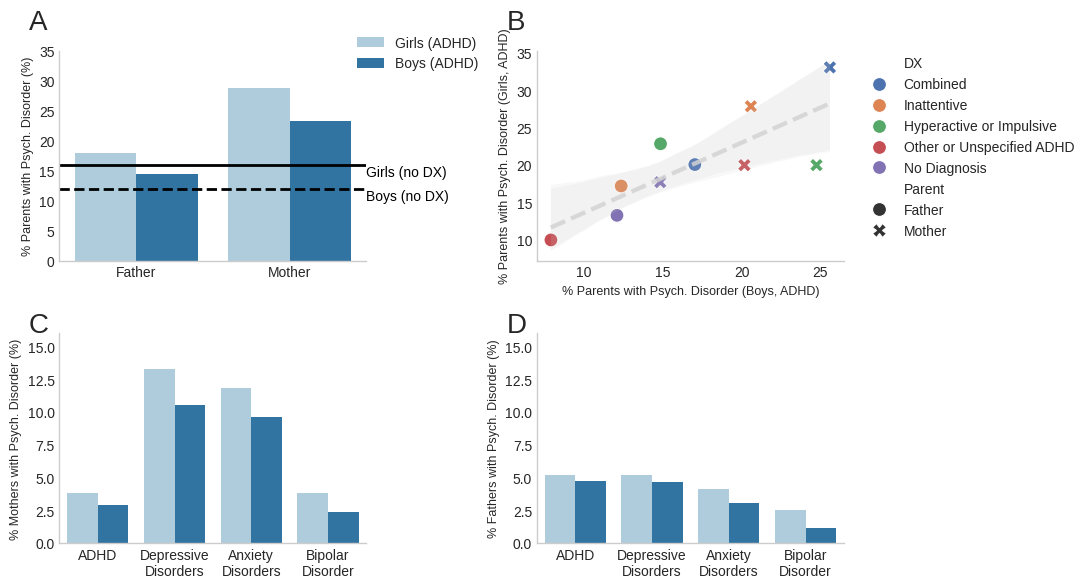

In [18]:
vis.plotting_style()

fig = plt.figure(figsize=(11,6))
gs = GridSpec(2, 2, figure=fig)

# A
data_to_plot = df_A_C[(df_A_C['DX']=='ADHD')]  
data_to_plot['sex'] = data_to_plot['sex'].map({'female': 'Girls (ADHD)', 'male': 'Boys (ADHD)'})
ax = fig.add_subplot(gs[0, 0]) 
vis.barplot( 
            data_to_plot, ax=ax, x='Parent', hue='sex', y="perc", 
            ylabel='% Parents with Psych. Disorder (%)',
            y_pos=1.2,
            ylim=[0,35], bbox_to_anchor=(.95, 1.1), subplot='A',
            ) 

# add lineplot for overall ADHD (boys and girls)
data_to_plot = df_A_C[(df_A_C['DX']=='No Diagnosis Given')]  
f_overall = data_to_plot[(data_to_plot['Parent']=='Mother')]
m_overall = data_to_plot[(data_to_plot['Parent']=='Father')]

# plot girls (no DX)
y = int(f_overall['perc'].mean())
plt.axhline(y=y, color='black', linestyle='solid')
plt.text(x=len(f_overall)-.5, y=y, s=f'Girls (no DX)', color='black', verticalalignment='top')
# plot boys (no DX)
y = int(m_overall['perc'].mean())
plt.axhline(y=y, color='black', linestyle='dashed')
plt.text(x=len(m_overall)-.5, y=y, s=f'Boys (no DX)', color='black', verticalalignment='top')

# B
df_A_C['DX_new'] = df_A_C['DX'].map({'ADHD-Combined Type': 'Combined', 
                                'ADHD-Inattentive Type': 'Inattentive',
                                'ADHD-Hyperactive/Impulsive Type': 'Hyperactive or Impulsive',
                                'Other Specified Attention-Deficit/Hyperactivity Disorder': 'Other or Unspecified ADHD',
                                'Unspecified Attention-Deficit/Hyperactivity Disorder': 'Other or Unspecified ADHD',
                                'No Diagnosis Given': 'No Diagnosis'
                                })

vis.plotting_style(palette='deep')
ax = fig.add_subplot(gs[0, 1])
dx = ['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis'] 
data_to_plot = df_A_C[(df_A_C['DX_new'].isin(dx))] .pivot_table(index=[ 'Parent', 'DX_new'],  columns='sex', values='perc').reset_index() \
                .rename({'DX_new': 'DX'}, axis=1)
sns.regplot(x='male', y='female', data=data_to_plot, fit_reg=True, scatter=False, 
            color='lightgray', line_kws={'color': 'lightgray', 'linestyle': '--','alpha': 0.6}, 
            ci=95, ax=ax)
vis.scatterplot(x='male', 
                y='female', 
                ax=ax,
                hue='DX', 
                hue_order=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis'],
                style='Parent', 
                xlabel='% Parents with Psych. Disorder (Boys, ADHD)',
                ylabel='% Parents with Psych. Disorder (Girls, ADHD)',
                df=data_to_plot,
                y_pos=1.2,
                bbox_to_anchor=(1.05, 1),
                subplot='B',
                )

# C
vis.plotting_style(palette='Paired')
ax = fig.add_subplot(gs[1, 0])
data_to_plot = df_B[(df_B['DX'].isin(['ADHD'])) & (df_B['Parent']=='Mother')]
vis.barplot( 
            data_to_plot, ax=ax, x='Parent DX', hue='sex', y="perc", 
            ylabel='% Mothers with Psych. Disorder (%)', legend=False,
            ylim=[0,16], bbox_to_anchor=(.95, 1.1), subplot='C',
            ) 
# D
ax = fig.add_subplot(gs[1, 1])

data_to_plot = df_B[(df_B['DX'].isin(['ADHD'])) & (df_B['Parent']=='Father')]
vis.barplot( 
            data_to_plot, ax=ax, x='Parent DX', hue='sex', y="perc", 
            ylabel='% Fathers with Psych. Disorder (%)', legend=False,
            ylim=[0,16], bbox_to_anchor=(.95, 1.1), subplot='D',
            ) 

# plt.subplots_adjust(left=0.13, bottom=0.15, right=0.95, top=1.1, wspace=0.4, hspace=0.4)

<Axes: ylabel='% Fathers with Psych. Disorder (%)'>

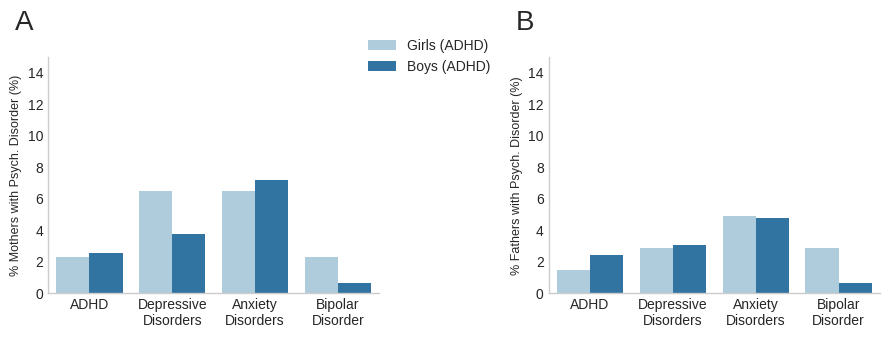

In [9]:
vis.plotting_style()

fig = plt.figure(figsize=(9,6))
gs = GridSpec(2, 2, figure=fig)


# A
data_to_plot = df_B[(df_B['DX'].isin(['No Diagnosis Given'])) & (df_B['Parent']=='Mother')]
data_to_plot['sex'] = data_to_plot['sex'].map({'female': 'Girls (ADHD)', 'male': 'Boys (ADHD)'})
ax = fig.add_subplot(gs[0, 0])
vis.barplot(data_to_plot, ax=ax, x='Parent DX', hue='sex', y="perc", 
            ylabel='% Mothers with Psych. Disorder (%)', legend=True,
            ylim=[0,15], bbox_to_anchor=(.95, 1.1), subplot='A',
            ) 

# B
data_to_plot = df_B[(df_B['DX'].isin(['No Diagnosis Given'])) & (df_B['Parent']=='Father')]
ax = fig.add_subplot(gs[0, 1])
vis.barplot(data_to_plot, ax=ax, x='Parent DX', hue='sex', y="perc", 
            ylabel='% Fathers with Psych. Disorder (%)', legend=False,
            ylim=[0,15], bbox_to_anchor=(.95, 1.1), subplot='B',
            ) 

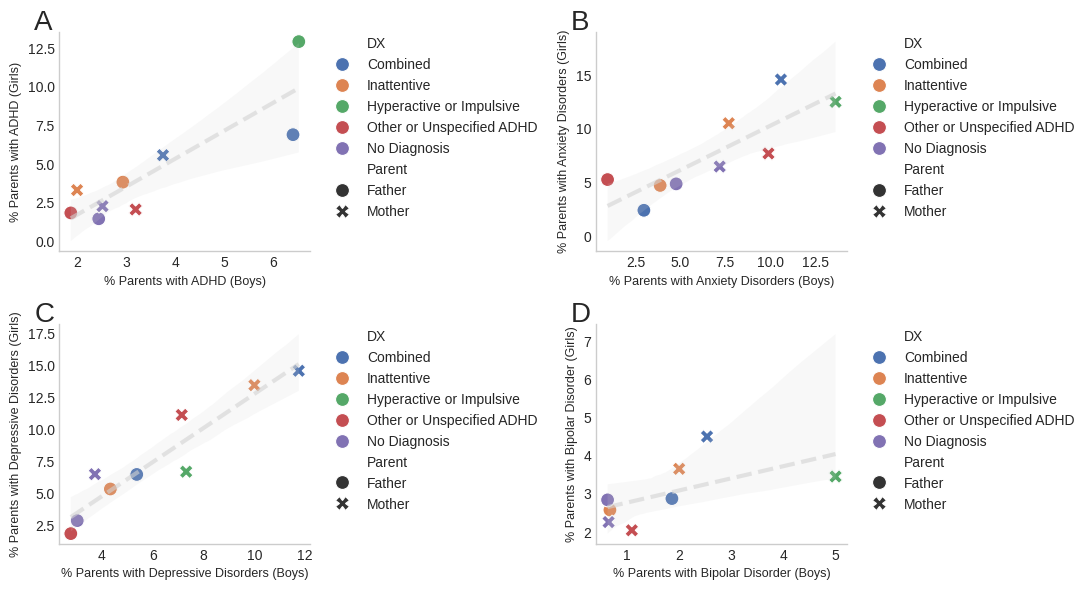

In [19]:
vis.plotting_style(palette='deep')

fig = plt.figure(figsize=(11,6))
gs = GridSpec(2, 2, figure=fig)

df_B['DX_new'] = df_B['DX'].map({'ADHD-Combined Type': 'Combined', 
                            'ADHD-Inattentive Type': 'Inattentive',
                            'ADHD-Hyperactive/Impulsive Type': 'Hyperactive or Impulsive',
                            'Other Specified Attention-Deficit/Hyperactivity Disorder': 'Other or Unspecified ADHD',
                            'Unspecified Attention-Deficit/Hyperactivity Disorder': 'Other or Unspecified ADHD',
                            'No Diagnosis Given': 'No Diagnosis'
                            })
dx = ['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis'] 

# A
ax = fig.add_subplot(gs[0, 0])
data_to_plot = df_B[(df_B['DX_new'].isin(dx)) & (df_B['Parent DX']=='ADHD')] \
                .pivot_table(index=['Parent DX', 'Parent', 'DX_new'],  columns='sex', values='perc').reset_index() \
                    .rename({'DX_new': 'DX'}, axis=1)
vis.scatterplot(x='male', 
                y='female', 
                ax=ax,
                hue='DX', 
                hue_order=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis'],
                style='Parent', 
                xlabel='% Parents with ADHD (Boys)',
                ylabel='% Parents with ADHD (Girls)',
                df=data_to_plot,
                bbox_to_anchor=(1.05, 1),
                subplot='A',
                )

# B
ax = fig.add_subplot(gs[0, 1])
data_to_plot = df_B[(df_B['DX_new'].isin(dx)) & (df_B['Parent DX']=='Anxiety Disorders')] \
                .pivot_table(index=['Parent DX', 'Parent', 'DX_new'],  columns='sex', values='perc').reset_index() \
                    .rename({'DX_new': 'DX'}, axis=1)
vis.scatterplot(x='male', 
                y='female', 
                ax=ax,
                hue='DX', 
                hue_order=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis'],
                style='Parent', 
                xlabel='% Parents with Anxiety Disorders (Boys)',
                ylabel='% Parents with Anxiety Disorders (Girls)',
                df=data_to_plot,
                bbox_to_anchor=(1.05, 1),
                subplot='B',
                )

# C
ax = fig.add_subplot(gs[1, 0])
data_to_plot = df_B[(df_B['DX_new'].isin(dx)) & (df_B['Parent DX']=='Depressive Disorders')] \
                .pivot_table(index=['Parent DX', 'Parent', 'DX_new'],  columns='sex', values='perc').reset_index() \
                .rename({'DX_new': 'DX'}, axis=1)
vis.scatterplot(x='male', 
                y='female', 
                ax=ax,
                hue='DX', 
                hue_order=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis'],
                style='Parent', 
                xlabel='% Parents with Depressive Disorders (Boys)',
                ylabel='% Parents with Depressive Disorders (Girls)',
                df=data_to_plot,
                bbox_to_anchor=(1.05, 1),
                subplot='C',
                )

# D
ax = fig.add_subplot(gs[1, 1])
data_to_plot = df_B[(df_B['DX_new'].isin(dx)) & (df_B['Parent DX']=='Bipolar Disorder')] \
                .pivot_table(index=['Parent DX', 'Parent', 'DX_new'],  columns='sex', values='perc').reset_index() \
                .rename({'DX_new': 'DX'}, axis=1)
vis.scatterplot(x='male', 
                y='female', 
                ax=ax,
                hue='DX',
                hue_order=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis'], 
                style='Parent', 
                xlabel='% Parents with Bipolar Disorder (Boys)',
                ylabel='% Parents with Bipolar Disorder (Girls)',
                df=data_to_plot,
                bbox_to_anchor=(1.05, 1),
                subplot='D',
                )


In [ ]:
# STATS FOR FIGURE 3

## Children with ADHD are more likely to have parents with psychiatric disorders compared to children with no diagnosis
# In particular, mothers of children with ADHD are more likely than fathers to be diagnosed with a psych disorder (not true for children with No Diagnosis)
# This maternal link is even stronger for girls with ADHD. 

# get data for stats
adhd_dx = df_A_C[(df_A_C['DX']=='ADHD')]  
no_diagnosis_dx = df_A_C[(df_A_C['DX']=='No Diagnosis Given')]  

data = pd.concat([adhd_dx, no_diagnosis_dx])

results_dx_overall = perform_flexible_proportion_comparison(
    df=data,
    compare_col='DX',
    count_col='count',
    overall_count_col='overall_count',
    # group_col='DX'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

results_dx_overall = perform_flexible_proportion_comparison(
    df=data,
    compare_col='Parent',
    count_col='count',
    overall_count_col='overall_count',
    group_col='DX'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

results_dx_overall = perform_flexible_proportion_comparison(
    df=data,
    compare_col='DX',
    count_col='count',
    overall_count_col='overall_count',
    group_col='Parent'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

results_dx_overall = perform_flexible_proportion_comparison(
    df=data,
    compare_col='Parent',
    count_col='count',
    overall_count_col='overall_count',
    group_col='sex'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

results_dx_overall = perform_flexible_proportion_comparison(
    df=adhd_dx,
    compare_col='sex',
    count_col='count',
    overall_count_col='overall_count',
    group_col='Parent'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)

# STATS FOR SUBPLOT B
# Parents of children with ADHD (both boys and girls) are more likely to have a diagnosis of anxiety and depression than ADHD.
results_dx_overall = perform_flexible_proportion_comparison(
    df=df_B,
    compare_col='Parent',
    count_col='count',
    overall_count_col='overall_count',
    group_col='Parent DX'
)
print("\nResults comparing DX overall:")
print(results_dx_overall)


--- Results with Holm-Bonferroni Correction ---

--- Comparison: ADHD vs. No Diagnosis Given ---
Z-statistic: 1.408
Uncorrected P-value: 0.159
Holm-Bonferroni Corrected P-value: 0.159
Fail to reject null hypothesis at alpha=0.05.
There is no significant difference in rates between ADHD and No Diagnosis Given.

Results comparing DX overall:
   DX_1                DX_2  z_statistic   p_value  DX_1_count  DX_1_total  \
0  ADHD  No Diagnosis Given     1.407719  0.159214         128         713   

   DX_2_count  DX_2_total  p_corrected_bonferroni  reject_null_bonferroni  \
0          21         158                0.159214                   False   

   p_corrected_holm  reject_null_holm  
0          0.159214             False  

--- Results with Holm-Bonferroni Correction (Grouped by 'DX') ---

--- Comparison: Father vs. Mother (within DX = 'ADHD') ---
Z-statistic: -4.820
Uncorrected P-value: 0.000
Holm-Bonferroni Corrected P-value: 0.000
Reject null hypothesis at alpha=0.05.
There is a s

### Figure 4
* Developemental trajectory of children with ADHD

In [5]:

def get_temperament1(df, groups, groupby=['sex']):
    # infant Temperament (% count)
    infant_temperament_cols = [f'PreInt_DevHx,temp_{str(i).zfill(2)}' for i in np.arange(1,12)]

    ## get all infant Temperament data for plotting
    df_infant = pd.DataFrame()
    for col in infant_temperament_cols:
        df2 = get_plot_data(groups, df, col=col, col_values=[1], groupby=groupby)
        df2['Temperament'] = col
        df_infant = pd.concat([df_infant, df2])
    df_infant['Attribute'] = 'Temperament'
    
    # get relevent cols
    df_out = df_infant[df_infant['Temperament'].isin(infant_temperament_cols)]
    temperament_rename = ['Easy to soothe when upset', 'Difficult to soothe','Colic',
                          'Eating Difficulties','Sleeping Difficulties', 'Baby did not enjoy body contact',
                        'Overly sensitive to sound', 'Baby was "limp" or stiff', 'Easily adaptable', 
                        'Slow to warm up','Problems with social relatedness']

    new_names = {}
    for old_name, new_name in zip(infant_temperament_cols, temperament_rename):
        new_names.update({old_name: new_name})
    df_out['Temperament'] = df_out['Temperament'].map(new_names)
    df_out['Type'] = df_out['Temperament'].apply(lambda x: map_temperament_categories(x))
    df_out['sex'] = df_out['sex'].map({'female': 'Girls', 'male': 'Boys'})
    
    return df_out


def get_temperament2(df, groups, groupby=['sex']):
    """on average, how many temperamental problems do children have
    df (pd dataframe):
    groups (list of dict): 
    groupby (list of str): ['sex']
    """
    from hbn.features.build_features import _index_dataframe_by_columns_values

    temperamental_cols = ['PreInt_DevHx,temp_02', 'PreInt_DevHx,temp_03', 'PreInt_DevHx,temp_04', 'PreInt_DevHx,temp_05',
                        'PreInt_DevHx,temp_06', 'PreInt_DevHx,temp_07', 'PreInt_DevHx,temp_08', 'PreInt_DevHx,temp_09', 'PreInt_DevHx,temp_10']
    
    df_all = pd.DataFrame()
    for group in groups:
        
        # filter data
        df_filter = _index_dataframe_by_columns_values(dataframe=df, columns=list(group.keys()), values_list=list(group.values()))
        df_grouped = df_filter.groupby('Identifiers').first().reset_index()
        df_melt = pd.melt(df_grouped, value_vars=temperamental_cols, id_vars=groupby + ['Identifiers']) \
                .rename(columns={'variable': 'Temperament', 'value': 'Score'})
        df_count = df_melt.groupby(groupby).apply(lambda x: x['Score'].sum()).reset_index(name='num_dev_problems')
        key = list(group.keys())[0]
        df_count['DX'] = group[key][0]
        df_all = pd.concat([df_all, df_count])

    df_all['sex'] = df_all['sex'].map({'female': 'Girls', 'male': 'Boys'})

    return df_all


def get_development_data(df, groups, groupby=['sex']):
    # infant developmentally normal? 
    
    df_out = get_plot_data(groups, df, col='PreInt_DevHx,dev_normal', col_values=[1], groupby=groupby)
    df_out['sex'] = df_out['sex'].map({'female': 'Girls', 'male': 'Boys'})

    return df_out

def map_temperament_categories(x):
    """overall what % of kids with ADHD and No Diagnosis have temperamental problems?
    """
    data_dict = {'Difficult Temperament': [
        'Difficult to soothe', 'Colic',
        'Eating Difficulties', 'Sleeping Difficulties',
        'Baby did not enjoy body contact', 'Overly sensitive to sound',
        'Baby was "limp" or stiff', 'Slow to warm up',
        'Problems with social relatedness'],
        'Easy Temperament':['Easy to soothe when upset', 'Easily adaptable']
        }
    for k, v in data_dict.items():
        if x in v:
            return k

def get_skills_data(df, groups, skills=['motor', 'language'], groupby=['sex']):
    from hbn.features.build_features import _index_dataframe_by_columns_values

    # get skills data
    df_skills_all = pd.DataFrame()
    for group in groups:
        for skill in skills:
            cols = np.arange(1,12)
            if skill=='language':
                cols = np.arange(15,18)
            df_filter = _index_dataframe_by_columns_values(dataframe=df, columns=list(group.keys()), values_list=list(group.values()))
            df_grouped = df_filter.groupby('Identifiers').first().reset_index()
            value_vars = [f'PreInt_DevHx,skill_age_{str(i).zfill(2)}' for i in cols]
            df_skills = pd.melt(df_grouped, value_vars=value_vars, id_vars=groupby + ['Identifiers']) \
                .rename(columns={'variable': 'Skill', 'value': 'Months (Onset)'})
            key = list(group.keys())[0]
            df_skills['DX'] = group[key][0]
            df_skills['Attribute'] = skill
            df_skills_all = pd.concat([df_skills_all, df_skills])

    rename_cols = {'PreInt_DevHx,skill_age_01': 'Held head up',
                'PreInt_DevHx,skill_age_02': 'Sat without help',
                'PreInt_DevHx,skill_age_03': 'Crawled',
                'PreInt_DevHx,skill_age_04': 'Stood',
                'PreInt_DevHx,skill_age_05': 'Cruised',
                'PreInt_DevHx,skill_age_06': 'Walked',
                'PreInt_DevHx,skill_age_07': 'Ran',
                'PreInt_DevHx,skill_age_08': 'Rode a tricycle',
                'PreInt_DevHx,skill_age_09': 'Tied shoes',
                'PreInt_DevHx,skill_age_10': 'Fed self',
                'PreInt_DevHx,skill_age_11': 'Dressed self',
                'PreInt_DevHx,skill_age_15': 'Spoke first word',
                'PreInt_DevHx,skill_age_16': 'Named objects',
                'PreInt_DevHx,skill_age_17': 'Spoke 2/3 words'
                }
    df_skills_all['Skill'] = df_skills_all['Skill'].map(rename_cols)

    # map motor skills
    def map_skills(x):
        out = '<20 months'
        late_skills = ['Tied shoes', 'Fed self', 'Dressed self', 'Rode a tricycle']
        for skill in late_skills:
            if skill==x:
                out = '>20 months'
        return out
    
    df_skills_all['development'] = df_skills_all['Skill'].apply(lambda x: map_skills(x))
    df_skills_all = df_skills_all.dropna(how='any').reset_index(drop=True)
    df_skills_all['sex'] = df_skills_all['sex'].map({'female': 'Girls', 'male': 'Boys'})
    
    return df_skills_all

In [6]:

# get data for these plots
df_DevHx = raw_scores.get_data(
            release='Release11_Apr2024',
            assessment='parent', 
            cols_to_filter=None,
            vals_to_filter=None,
            measure='PreInt_DevHx',
            features=None
            )

# what % of children have temperamental problems (broken down by specific problem)
df_temperament1 = get_temperament1(df=df_DevHx, groups=compare_groups, groupby=['sex'])

# how many temperamental problems do children have (sum across all specific problems)
df_temperament2 = get_temperament2(df=df_DevHx, groups=compare_groups, groupby=['sex'])

# developmentally normal? 
df_development = get_development_data(df=df_DevHx, groups=compare_groups, groupby=['sex'])

# get skills data for infants
# df_skills = get_skills_data(df=df_DevHx, skills=['motor', 'language'], groupby=['Identifiers', 'DX_Cat_Name_New', 'DX_Subtype_Name', 'DX_ADHD', 'sex'])
df_skills = get_skills_data(df=df_DevHx, groups=compare_groups, skills=['motor', 'language'], groupby=['sex'])

                     Type    sex                  DX   count  overall_count  \
0   Difficult Temperament   Boys                ADHD  2138.0          15471   
8   Difficult Temperament   Boys  No Diagnosis Given   122.0           1424   
12  Difficult Temperament  Girls                ADHD   897.0           6399   
20  Difficult Temperament  Girls  No Diagnosis Given   116.0           1232   

         perc  
0   13.819404  
8    8.567416  
12  14.017815  
20   9.415584  

--- Results with Holm-Bonferroni Correction (Grouped by 'DX') ---

--- Comparison: Boys vs. Girls (within DX = 'ADHD') ---
Z-statistic: -0.386
Uncorrected P-value: 0.699
Holm-Bonferroni Corrected P-value: 0.891
Fail to reject null hypothesis at alpha=0.05.
There is no significant difference in rates between Boys and Girls.

--- Comparison: Boys vs. Girls (within DX = 'No Diagnosis Given') ---
Z-statistic: -0.763
Uncorrected P-value: 0.445
Holm-Bonferroni Corrected P-value: 0.891
Fail to reject null hypothesis at alpha

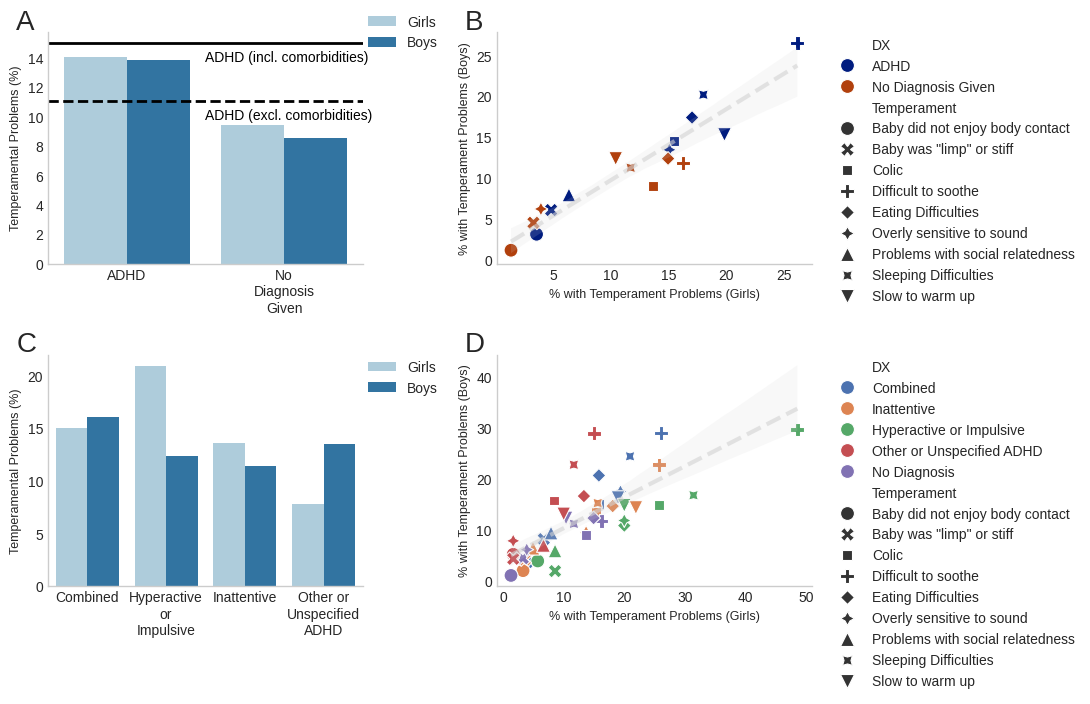

In [7]:
vis.plotting_style(palette='Paired')
fig = plt.figure(figsize=(11,7))
gs = GridSpec(2, 2, figure=fig)

def map_dx():
    return {'ADHD-Combined Type': 'Combined', 
            'ADHD-Inattentive Type': 'Inattentive',
            'ADHD-Hyperactive/Impulsive Type': 'Hyperactive or Impulsive',
            'Other Specified Attention-Deficit/Hyperactivity Disorder': 'Other or Unspecified ADHD',
            'Unspecified Attention-Deficit/Hyperactivity Disorder': 'Other or Unspecified ADHD',
            'No Diagnosis Given': 'No Diagnosis'
            }

# A
dx = 'ADHD'
df_temperament1_overall = df_temperament1.groupby(['Type', 'sex', 'DX']) \
    .agg(
        count=('count', 'sum'),
        overall_count=('overall_count', 'sum')
    ) \
    .reset_index()
df_temperament1_overall['perc'] = (df_temperament1_overall['count'] / df_temperament1_overall['overall_count']) * 100

data_to_plot = df_temperament1_overall[(df_temperament1_overall['DX'].isin([dx, 'No Diagnosis Given']))
                                      & (df_temperament1_overall['Type']=='Difficult Temperament')]
ax = fig.add_subplot(gs[0, 0])
vis.barplot(x='DX', 
            y='perc', 
            hue='sex', 
            data=data_to_plot.sort_values(by='sex', ascending=False), 
            ylim=None, 
            ylabel='Temperamental Problems (%)',
            subplot='A',
            bbox_to_anchor=(1.0, 1.1)
            )

print(data_to_plot)
# To compare 'sex' within each 'DX':
results_sex_by_dx = perform_flexible_proportion_comparison(
    df=data_to_plot,
    compare_col='sex',
    count_col='count',
    overall_count_col='overall_count',
    group_col='DX'
)
print("\nResults comparing sex within each DX:")
print(results_sex_by_dx)

# To compare 'sex' within each 'DX':
results_by_dx = perform_flexible_proportion_comparison(
    df=data_to_plot,
    compare_col='DX',
    count_col='count',
    overall_count_col='overall_count',
)
print("\nResults comparing DX:")
print(results_by_dx)

# plot horizontal lines for adhd (with/without comorbidities)
data_to_plot_comorbid = df_temperament1_overall[(df_temperament1_overall['DX'].isin(['adhd_all_comorbidities', 'adhd_no_comorbidities']))
                                      & (df_temperament1_overall['Type']=='Difficult Temperament')]

all_comorbid = data_to_plot_comorbid[data_to_plot_comorbid['DX']=='adhd_all_comorbidities']
no_comorbid = data_to_plot_comorbid[data_to_plot_comorbid['DX']=='adhd_no_comorbidities']

# plot girls (no DX)
y = (all_comorbid['perc'].mean())
ax.axhline(y=y, color='black', linestyle='solid')
ax.text(x=len(all_comorbid)-1.5, y=y-.5, s=f'ADHD (incl. comorbidities)', color='black', verticalalignment='top')
# plot boys (no DX)
y = (no_comorbid['perc'].mean())
ax.axhline(y=y, color='black', linestyle='dashed')
ax.text(x=len(no_comorbid)-1.5, y=y-.5, s=f'ADHD (excl. comorbidities)', color='black', verticalalignment='top')

# B
vis.plotting_style(palette='dark')
dx = 'ADHD'
data_to_plot = df_temperament1[(df_temperament1['DX'].isin([dx, 'No Diagnosis Given'])) \
                              & (df_temperament1['Type']=='Difficult Temperament')]

# Use pivot_table to reshape the data
df_pivot = data_to_plot.pivot_table(
    index=['DX', 'Temperament'],  # Keep these columns as is
    columns='sex',
    values='perc',
).reset_index()
df_pivot.columns.name = None  # Remove the column level name

print(df_pivot)

ax = fig.add_subplot(gs[0, 1])
vis.scatterplot(y='Boys', 
                x='Girls', 
                ax=ax,
                hue='DX', 
                xlabel=f'% with Temperament Problems (Girls)',
                ylabel='% with Temperament Problems (Boys)',
                style='Temperament', 
                df=df_pivot,
                subplot='B',
                bbox_to_anchor=(1.05, 1)
                )

df_temperament1_overall['DX_new'] = df_temperament1_overall['DX'].map(map_dx())
# C
vis.plotting_style(palette='Paired')
dx = ['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD']
data_to_plot = df_temperament1_overall[(df_temperament1_overall['DX_new'].isin(dx))
                                      & (df_temperament1_overall['Type']=='Difficult Temperament')]
ax = fig.add_subplot(gs[1, 0])
vis.barplot(x='DX_new', 
            y='perc', 
            hue='sex', 
            data=data_to_plot.sort_values(by='sex', ascending=False), 
            ylim=None, 
            ylabel='Temperamental Problems (%)',
            subplot='C',
            # xticklabels=dx,
            bbox_to_anchor=(1.0, 1)
            )

print(data_to_plot[['sex', 'perc', 'DX']])
# To compare 'sex' within each 'DX':
results_sex_by_dx = perform_flexible_proportion_comparison(
    df=data_to_plot,
    compare_col='sex',
    count_col='count',
    overall_count_col='overall_count',
    group_col='DX'
)
print("\nResults comparing sex within each DX:")
print(results_sex_by_dx)

# D
vis.plotting_style(palette='deep')
dx = ['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'Other or Unspecified ADHD', 'No Diagnosis']
df_temperament1['DX_new'] = df_temperament1['DX'].map(map_dx())
data_to_plot = df_temperament1[(df_temperament1['DX_new'].isin(dx))
                            & (df_temperament1['Type']=='Difficult Temperament')]
# Use pivot_table to reshape the data
df_pivot = data_to_plot.pivot_table(
    index=['DX_new', 'Temperament'],  # Keep these columns as is
    columns='sex',
    values='perc',
).reset_index()
df_pivot.columns.name = None  # Remove the column level name
df_pivot = df_pivot.rename({"DX_new": 'DX'}, axis=1)

ax = fig.add_subplot(gs[1, 1])
vis.scatterplot(y='Boys', 
                x='Girls', 
                ax=ax,
                hue='DX', 
                hue_order=dx,
                xlabel=f'% with Temperament Problems (Girls)',
                ylabel='% with Temperament Problems (Boys)',
                style='Temperament', 
                df=df_pivot,
                subplot='D',
                bbox_to_anchor=(1.05, 1)
                )

for dx in df_pivot['DX'].unique():

    dx_grouped = df_pivot[df_pivot['DX']==dx]
    b_top = dx_grouped.sort_values(by='Boys', ascending=False).head(1)
    g_top = dx_grouped.sort_values(by='Girls', ascending=False).head(1)
    print(f'{b_top['Temperament'].values[0]} is top problem for boys with {dx}({b_top['Boys'].values[0]}%)')
    print(f'{g_top['Temperament'].values[0]} is top problem for girls with {dx}({b_top['Girls'].values[0]}%)')
    


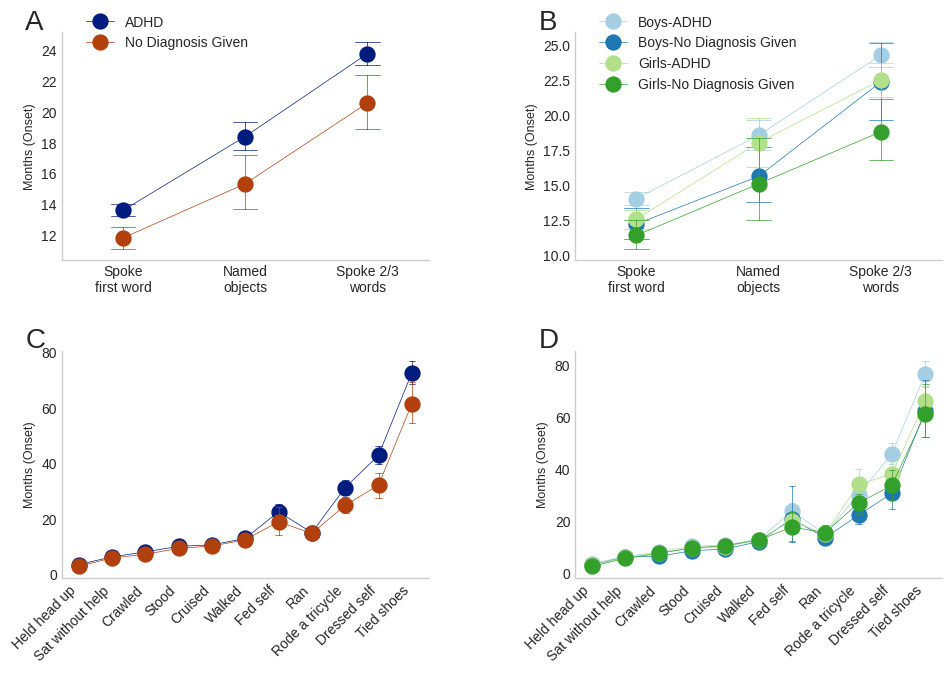

In [28]:
vis.plotting_style(palette='dark')
fig = plt.figure(figsize=(11, 7))
gs = GridSpec(2, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0, 0])
data_to_plot = df_skills[(df_skills['DX'].isin(['ADHD', 'No Diagnosis Given'])) & (df_skills['Attribute']=='language')] \
        .sort_values(by='Months (Onset)', ascending=True)
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot, 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='DX',
        textwrapping_x=True,
        bbox_to_anchor=(.05, 1.1),
        ylim=None,
        subplot='A'
        )       

# B
vis.plotting_style(palette='Paired')
ax = fig.add_subplot(gs[0, 1])
data_to_plot = df_skills[(df_skills['DX'].isin(['ADHD', 'No Diagnosis Given'])) & (df_skills['Attribute']=='language')] \
        .sort_values(by='Months (Onset)', ascending=True)
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot, 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='sex_dx',
        hue_order=['Boys-ADHD', 'Boys-No Diagnosis Given', 'Girls-ADHD', 'Girls-No Diagnosis Given'],
        textwrapping_x=True,
        bbox_to_anchor=(.05, 1.1),
        ylim=None,
        subplot='B'
        )

# C
vis.plotting_style(palette='dark')
ax = fig.add_subplot(gs[1, 0])
data_to_plot = df_skills[(df_skills['DX'].isin(['ADHD', 'No Diagnosis Given'])) \
                         & (df_skills['Attribute']=='motor') \
                         ] \
        .sort_values(by=['Months (Onset)', 'DX'], ascending=True)
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot, 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='DX',
        textwrapping_x=False,
        ylim=None,
        legend=False,
        subplot='C'
        )
plt.xticks(rotation=45, ha='right')

# D
vis.plotting_style(palette='Paired')
ax = fig.add_subplot(gs[1, 1])
data_to_plot = df_skills[(df_skills['DX'].isin(['ADHD', 'No Diagnosis Given'])) \
                         & (df_skills['Attribute']=='motor') \
                         ]
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot.sort_values(by=['Months (Onset)'], ascending=True), 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='sex_dx',
        hue_order=['Boys-ADHD', 'Boys-No Diagnosis Given', 'Girls-ADHD', 'Girls-No Diagnosis Given'],
        textwrapping_x=False,
        ylim=None,
        legend=False,
        subplot='D'
        )
plt.xticks(rotation=45, ha='right')


plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.93, wspace=0.4, hspace=0.4)

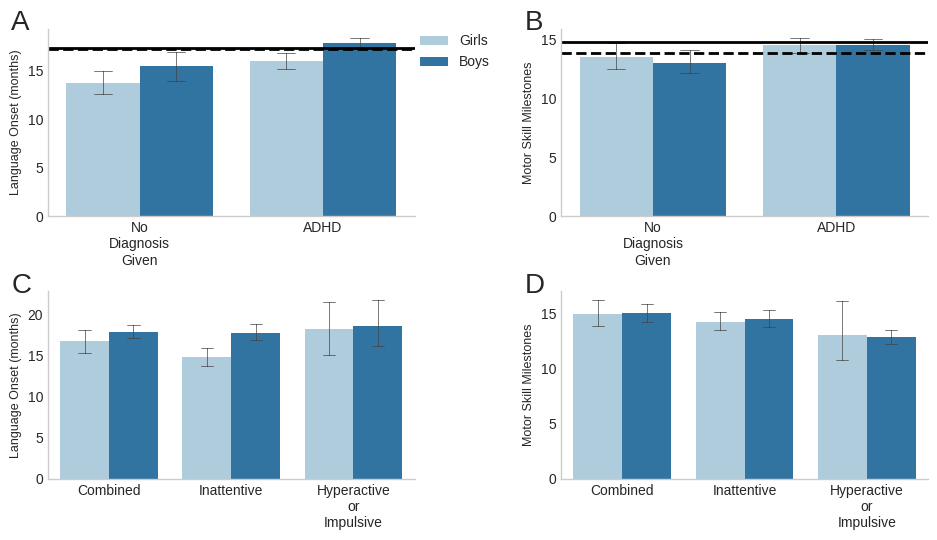

In [100]:
vis.plotting_style(palette='Paired')

fig = plt.figure(figsize=(11,6))
gs = GridSpec(2, 2, figure=fig)

# A
df_grouped = df_skills.groupby(['Identifiers', 'sex', 'DX', 'Attribute']) \
                .apply(lambda x: x['Months (Onset)'].mean()) \
                    .reset_index(name='Months (Onset)') 
data_to_plot = df_grouped[(df_grouped['DX'].isin(['ADHD', 'No Diagnosis Given'])) & (df_grouped['Attribute']=='language')]

ax = fig.add_subplot(gs[0, 0])
vis.barplot(x='DX', 
            y='Months (Onset)', 
            hue='sex', 
            data=data_to_plot,  
            ylabel='Language Onset (months)',
            subplot='A',
            legend=True,
            ylim=None,
            bbox_to_anchor=(1.0, 1)
            )
# plot horizontal lines for adhd (with/without comorbidities)
data_to_plot_comorbid = df_grouped[(df_grouped['DX'].isin(['adhd_all_comorbidities', 'adhd_no_comorbidities']))
                                      & (df_grouped['Attribute']=='language')]

all_comorbid = data_to_plot_comorbid[data_to_plot_comorbid['DX']=='adhd_all_comorbidities']
no_comorbid = data_to_plot_comorbid[data_to_plot_comorbid['DX']=='adhd_no_comorbidities']

# plot girls (no DX)
y = (all_comorbid['Months (Onset)'].mean())
plt.axhline(y=y, color='black', linestyle='solid')
# plt.text(x=0.5, y=y+.5, s=f'ADHD (incl. comorbidities)', color='black', verticalalignment='top')
# plot boys (no DX)
y = (no_comorbid['Months (Onset)'].mean())
plt.axhline(y=y, color='black', linestyle='dashed')
# plt.text(x=0.5, y=y-.5, s=f'ADHD (excl. comorbidities)', color='black', verticalalignment='top')

# B
data_to_plot = df_grouped[(df_grouped['DX'].isin(['ADHD', 'No Diagnosis Given'])) & (df_grouped['Attribute']=='motor')]
ax = fig.add_subplot(gs[0, 1])
vis.barplot(x='DX', 
            y='Months (Onset)', 
            hue='sex', 
            data=data_to_plot, 
            ylabel='Motor Skill Milestones',
            subplot='B',
            legend=False,
            ylim=None,
            bbox_to_anchor=(1.0, 1)
            )
# plot horizontal lines for adhd (with/without comorbidities)
data_to_plot_comorbid = df_grouped[(df_grouped['DX'].isin(['adhd_all_comorbidities', 'adhd_no_comorbidities']))
                                      & (df_grouped['Attribute']=='motor')]

all_comorbid = data_to_plot_comorbid[data_to_plot_comorbid['DX']=='adhd_all_comorbidities']
no_comorbid = data_to_plot_comorbid[data_to_plot_comorbid['DX']=='adhd_no_comorbidities']

# plot girls (no DX)
y = (all_comorbid['Months (Onset)'].mean())
plt.axhline(y=y, color='black', linestyle='solid')
# plt.text(x=0.5, y=y-.5, s=f'ADHD (incl. comorbidities)', color='black', verticalalignment='top')
# plot boys (no DX)
y = (no_comorbid['Months (Onset)'].mean())
plt.axhline(y=y, color='black', linestyle='dashed')
# plt.text(x=0.5, y=y-.5, s=f'ADHD (excl. comorbidities)', color='black', verticalalignment='top')

# C
df_grouped = df_skills.groupby(['Identifiers', 'sex', 'DX', 'Attribute']) \
                .apply(lambda x: x['Months (Onset)'].mean()) \
                    .reset_index(name='Months (Onset)') 
data_to_plot = df_grouped[(df_grouped['DX'].isin(['ADHD-Combined Type', 'ADHD-Inattentive Type', 'ADHD-Hyperactive/Impulsive Type'])) & (df_grouped['Attribute']=='language')]

ax = fig.add_subplot(gs[1, 0])
vis.barplot(x='DX', 
            y='Months (Onset)', 
            hue='sex', 
            hue_order=['Girls', 'Boys'],
            data=data_to_plot,  
            ylabel='Language Onset (months)',
            subplot='C',
            legend=False,
            ylim=None,
            xticklabels=['Combined', 'Inattentive', 'Hyperactive or Impulsive'],
            bbox_to_anchor=(1.0, 1)
            )
# D
data_to_plot = df_grouped[(df_grouped['DX'].isin(['ADHD-Combined Type', 'ADHD-Inattentive Type', 'ADHD-Hyperactive/Impulsive Type'])) & (df_grouped['Attribute']=='motor')]
ax = fig.add_subplot(gs[1, 1])
vis.barplot(x='DX', 
            y='Months (Onset)', 
            hue='sex', 
            hue_order=['Girls', 'Boys'],
            data=data_to_plot, 
            ylabel='Motor Skill Milestones',
            subplot='D',
            legend=False,
            ylim=None,
            xticklabels=['Combined', 'Inattentive', 'Hyperactive or Impulsive'],
            bbox_to_anchor=(1.0, 1)
            )


plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.90, wspace=0.4, hspace=0.4)

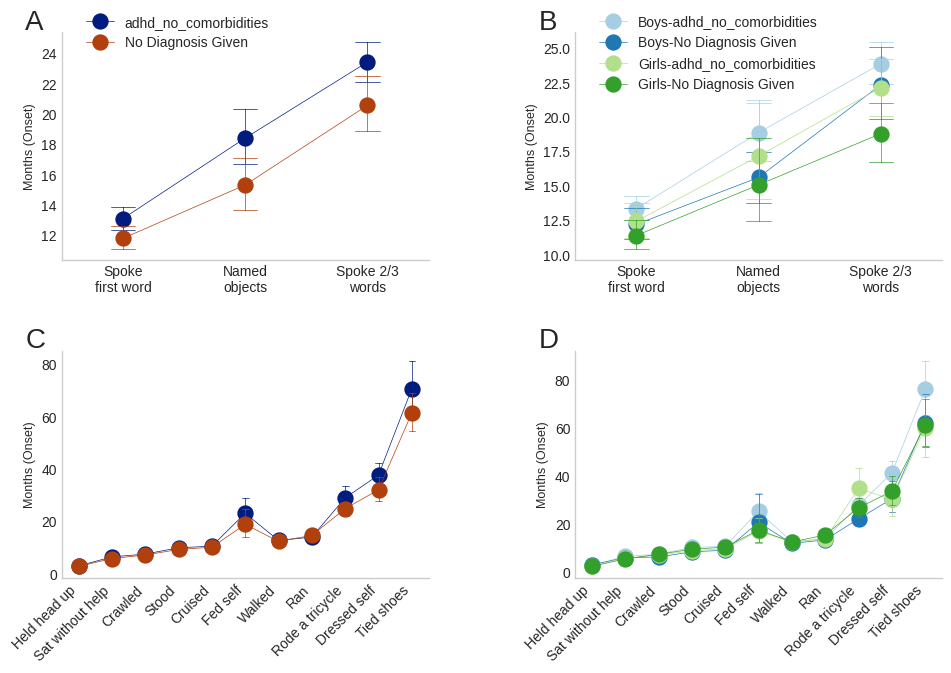

In [15]:
vis.plotting_style(palette='dark')
fig = plt.figure(figsize=(11, 7))
gs = GridSpec(2, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0, 0])
data_to_plot = df_skills[(df_skills['DX'].isin(['adhd_no_comorbidities', 'No Diagnosis Given'])) & (df_skills['Attribute']=='language')] \
        .sort_values(by='Months (Onset)', ascending=True)
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot, 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='DX',
        textwrapping_x=True,
        bbox_to_anchor=(.05, 1.1),
        ylim=None,
        subplot='A'
        )       

# B
vis.plotting_style(palette='Paired')
ax = fig.add_subplot(gs[0, 1])
data_to_plot = df_skills[(df_skills['DX'].isin(['adhd_no_comorbidities', 'No Diagnosis Given'])) & (df_skills['Attribute']=='language')] \
        .sort_values(by='Months (Onset)', ascending=True)
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot, 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='sex_dx',
        hue_order=['Boys-adhd_no_comorbidities', 'Boys-No Diagnosis Given', 'Girls-adhd_no_comorbidities', 'Girls-No Diagnosis Given'],
        textwrapping_x=True,
        bbox_to_anchor=(.05, 1.1),
        ylim=None,
        subplot='B'
        )

# C
vis.plotting_style(palette='dark')
ax = fig.add_subplot(gs[1, 0])
data_to_plot = df_skills[(df_skills['DX'].isin(['adhd_no_comorbidities', 'No Diagnosis Given'])) \
                         & (df_skills['Attribute']=='motor') \
                         ] \
        .sort_values(by=['Months (Onset)', 'DX'], ascending=True)
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot, 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='DX',
        hue_order=['adhd_no_comorbidities', 'No Diagnosis Given'],
        textwrapping_x=False,
        ylim=None,
        legend=False,
        subplot='C'
        )
plt.xticks(rotation=45, ha='right')

# D
vis.plotting_style(palette='Paired')
ax = fig.add_subplot(gs[1, 1])
data_to_plot = df_skills[(df_skills['DX'].isin(['adhd_no_comorbidities', 'No Diagnosis Given'])) \
                         & (df_skills['Attribute']=='motor') \
                         ]
data_to_plot['sex_dx'] = data_to_plot['sex'] + '-' + data_to_plot['DX']
vis.pointplot(
        ax=ax, 
        data=data_to_plot.sort_values(by=['Months (Onset)'], ascending=True), 
        y='Months (Onset)',
        ylabel='Months (Onset)',
        x='Skill', 
        hue='sex_dx',
        hue_order=['Boys-adhd_no_comorbidities', 'Boys-No Diagnosis Given', 'Girls-adhd_no_comorbidities', 'Girls-No Diagnosis Given'],
        textwrapping_x=False,
        ylim=None,
        legend=False,
        subplot='D'
        )
plt.xticks(rotation=45, ha='right')


plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.93, wspace=0.4, hspace=0.4)

In [34]:
from hbn.data import data_utils

# load model data

dx='DX_ADHD'

# load data for all models run in all comorbidities
model='july_adhd_dx_all_comorbidities'
summary_all, features_all = data_utils.load_model_results(model=model, release='Release11_Apr2024')
# remap diagnosis
summary_all[dx] = summary_all[dx].map(utils.remap_dx())
features_all[dx] = features_all[dx].map(utils.remap_dx())

# load data for all models run in no comorbidities
model='july_adhd_dx_no_comorbidities'
summary_no, features_no = data_utils.load_model_results(model=model, release='Release11_Apr2024')
# remap diagnosis
summary_no[dx] = summary_no[dx].map(utils.remap_dx())
features_no[dx] = features_no[dx].map(utils.remap_dx())

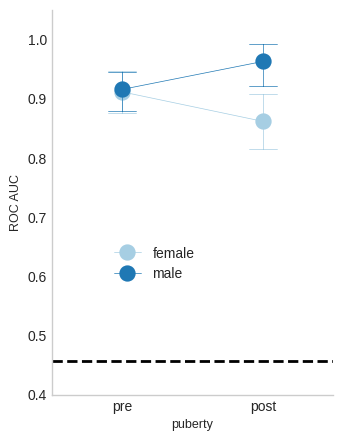

In [ ]:

vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# define variables
x = 'puberty'
hue = 'sex'
data = summary[(summary['data']=='data') & (summary['puberty'].isin(['pre', 'post']))]

# 1A
ax = fig.add_subplot(gs[0, 0])
fig = vis.pointplot(
            data=data, 
            y='roc_auc_score', 
            x=x, 
            order=['pre', 'post'],
            ylabel='ROC AUC', 
            hue=hue,
            hue_order=['female', 'male'],
            xlabel=None, 
            ylim=[.4, 1.05],
            subplot='A',
            ax=ax
            )

# plot null model
null = summary[summary['data']=='null'].groupby(x)['roc_auc_score'].mean().values
plt.axhline(y=null.mean(), color='k', linestyle='--')
